
Generating dataset for causal analysis (this may take a moment)...


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


Dataset generated.

Performing causal analysis...
Analyzing characters:
 - Man


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


 - Woman
 - Pregnant
 - Stroller
 - OldMan


...

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


 - MaleExecutive
 - FemaleExecutive
 - FemaleAthlete
 - MaleAthlete


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


 - FemaleDoctor
 - MaleDoctor
 - Dog
 - Cat


Analysis complete.

Displaying overall causal influences...


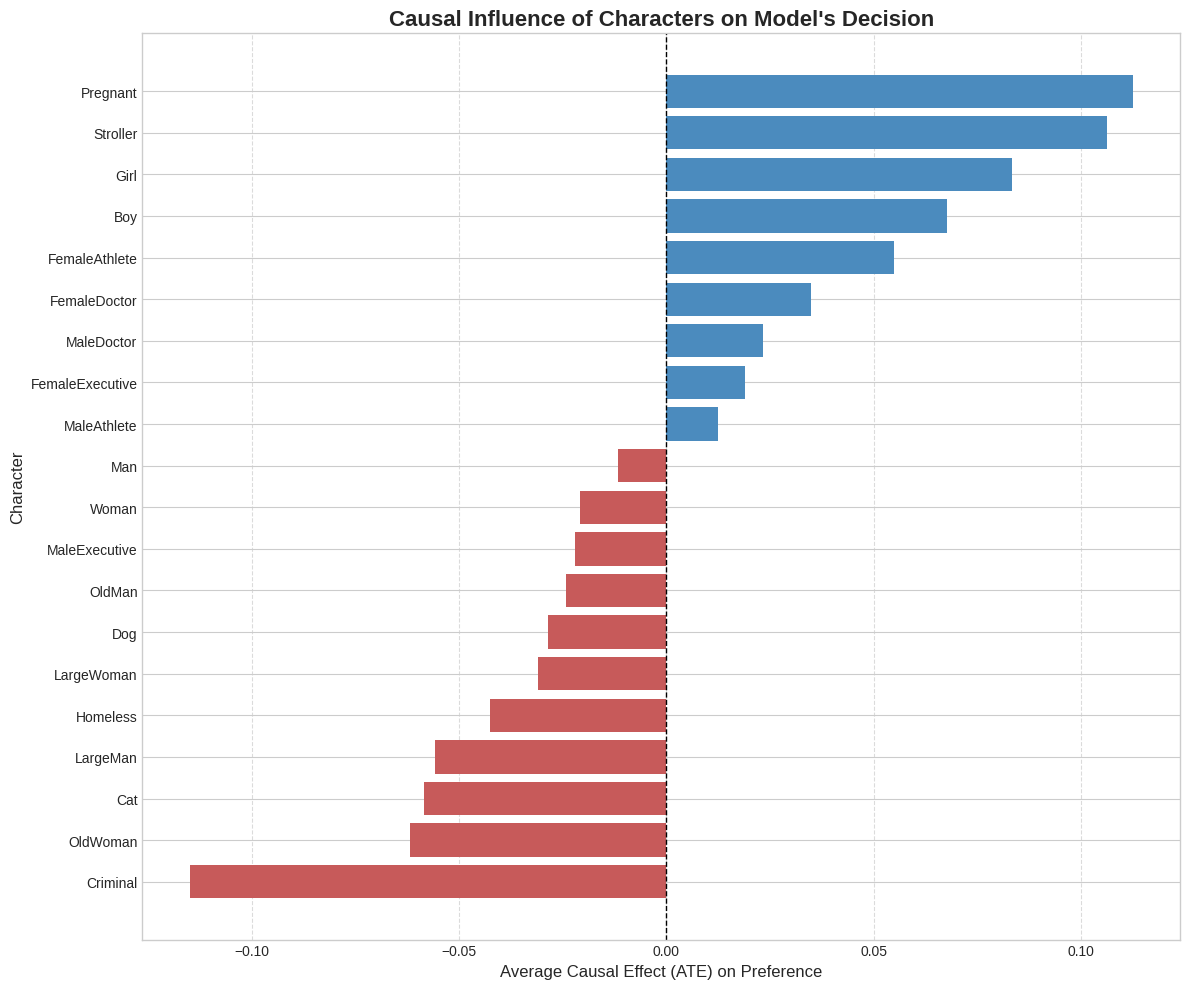

In [5]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import warnings

# Suppress warnings from the causal analysis library for a cleaner output
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np

import torch
import torch.nn as nn
import numpy as np

CHARACTERS = [
    'Intervention', 'Barrier', 'CrossingSignal',
    'Man', 'Woman', 'Pregnant', 'Stroller', 'OldMan', 'OldWoman',
    'Boy', 'Girl', 'Homeless', 'LargeWoman', 'LargeMan', 'Criminal',
    'MaleExecutive', 'FemaleExecutive', 'FemaleAthlete', 'MaleAthlete',
    'FemaleDoctor', 'MaleDoctor', 'Dog', 'Cat'
]

CHAR_TO_IDX = {char: idx for idx, char in enumerate(CHARACTERS)}

class MoralReasoningTransformer(nn.Module):
    def __init__(
        self,
        num_characters: int = 23,
        max_cardinality: int = 10,
        num_teams: int = 2,
        embed_dim: int = 64,
        num_heads: int = 2,
        num_layers: int = 2,
        dropout: float = 0.1
    ):
        super().__init__()

        self.num_characters = num_characters
        self.embed_dim = embed_dim
        self.char_embed_dim = embed_dim // 2
        self.card_team_embed_dim = embed_dim // 4

        # Compositional embeddings (character gets half, cardinality and team get quarter each)
        self.character_embedding = nn.Embedding(num_characters, self.char_embed_dim)
        self.cardinality_embedding = nn.Embedding(max_cardinality + 1, self.card_team_embed_dim)
        self.team_embedding = nn.Embedding(num_teams, self.card_team_embed_dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # CLS token for aggregation
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Classification head on CLS token
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 1)
        )

    def encode_outcome(self, counts, team_id):
        batch_size = counts.shape[0]

        character_ids = torch.arange(
            self.num_characters,
            device=counts.device
        ).unsqueeze(0).expand(batch_size, -1)

        char_emb = self.character_embedding(character_ids)  # (batch, 23, embed_dim//2)
        card_emb = self.cardinality_embedding(counts)        # (batch, 23, embed_dim//4)

        team_id_tensor = torch.full(
            (batch_size, self.num_characters),
            team_id,
            device=counts.device,
            dtype=torch.long
        )
        team_emb = self.team_embedding(team_id_tensor)       # (batch, 23, embed_dim//4)

        # Concatenate along last dimension: embed_dim//2 + embed_dim//4 + embed_dim//4 = embed_dim
        tokens = torch.cat([char_emb, card_emb, team_emb], dim=-1)

        return tokens

    def forward(self, scenarios):
        batch_size = scenarios.shape[0]

        outcome_0 = scenarios[:, 0, :]
        outcome_1 = scenarios[:, 1, :]

        tokens_0 = self.encode_outcome(outcome_0, team_id=0)
        tokens_1 = self.encode_outcome(outcome_1, team_id=1)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        all_tokens = torch.cat([cls_tokens, tokens_0, tokens_1], dim=1)

        encoded = self.transformer(all_tokens)
        cls_output = encoded[:, 0, :]
        logits = self.classifier(cls_output)

        return logits


def load_model(path='best_model.pt'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MoralReasoningTransformer()
    model.load_state_dict(torch.load(path, map_location=device)['model_state_dict'])
    model.to(device).eval()
    return model, device


def get_probs(model, device, scenario_tuple):
    """
    scenario_tuple: (dict_0, dict_1) where dicts have character names as keys
    Returns: [prob_outcome_0, prob_outcome_1] that sum to 1.0
    """
    outcome_0, outcome_1 = scenario_tuple

    vec_0 = np.zeros(23, dtype=np.int64)
    vec_1 = np.zeros(23, dtype=np.int64)

    for char, count in outcome_0.items():
        vec_0[CHAR_TO_IDX[char]] = count
    for char, count in outcome_1.items():
        vec_1[CHAR_TO_IDX[char]] = count

    scenario_1 = torch.tensor([[vec_0, vec_1]], dtype=torch.long).to(device)
    scenario_2 = torch.tensor([[vec_1, vec_0]], dtype=torch.long).to(device)

    with torch.no_grad():
        probs_1 = torch.sigmoid(model(scenario_1)).item()
        probs_2 = torch.sigmoid(model(scenario_2)).item()
        prob1 = (probs_1 + (1 - probs_2))/2
        prob0 = 1 - prob1
        return [prob0, prob1]


# Usage:
# model, device = load_model('best_model.pt')
# prob = get_probs(model, device, ({'Man': 3}, {'Criminal': 3}))
# print(prob)
# [0.8888750448822975, 0.11112495511770248]


# Usage:
# model, device = load_model('best_model.pt')
# prob = get_probs(model, device, ({'Man': 3}, {'Criminal': 3}))


def generate_causal_dataset(model, device, num_samples=10000):
    data = []
    scenarios_to_process = []
    sentient_chars = [c for c in CHARACTERS if c not in ['Intervention', 'Barrier', 'CrossingSignal']]

    for _ in range(num_samples):
        vec_0 = np.zeros(23, dtype=np.int64)
        vec_1 = np.zeros(23, dtype=np.int64)
        num_chars_0 = np.random.randint(1, 6)
        num_chars_1 = np.random.randint(1, 6)
        for _ in range(num_chars_0): vec_0[CHAR_TO_IDX[np.random.choice(sentient_chars)]] += 1
        for _ in range(num_chars_1): vec_1[CHAR_TO_IDX[np.random.choice(sentient_chars)]] += 1
        scenarios_to_process.append([vec_0, vec_1])

        record = {f"{char}_{i}": (vec_0 if i == 0 else vec_1)[j] for i in range(2) for j, char in enumerate(CHARACTERS)}
        data.append(record)

    df = pd.DataFrame(data)

    scenario_tensor = torch.tensor(scenarios_to_process, dtype=torch.long).to(device)
    with torch.no_grad():
        probabilities = torch.sigmoid(model(scenario_tensor)).cpu().numpy().flatten()

    df['outcome'] = probabilities
    return df

# --- CORRECTED CAUSAL ANALYSIS FUNCTION ---
def perform_causal_analysis(df):
    """
    Performs causal analysis with a simplified and more robust model.
    """
    causal_effects = {}
    sentient_chars = [c for c in CHARACTERS if c not in ['Intervention', 'Barrier', 'CrossingSignal']]

    # Create confounder variables: total number of individuals in each group
    df['total_0'] = df[[f'{c}_0' for c in sentient_chars]].sum(axis=1)
    df['total_1'] = df[[f'{c}_1' for c in sentient_chars]].sum(axis=1)

    print("Analyzing characters:")
    for char in sentient_chars:
        print(f" - {char}")
        # Treatment: Is the character present in group 1? (binary)
        df['treatment'] = (df[f'{char}_1'] > 0).astype(int)

        # We control for the total number of people in each group to isolate the character's value
        common_causes = ['total_0', 'total_1']

        # Build and run the causal model
        # The 'dot_graph' will show the simplified causal relationships
        model = CausalModel(
            data=df,
            treatment='treatment',
            outcome='outcome',
            common_causes=common_causes,
            graph=f"digraph {{ treatment -> outcome; total_0 -> treatment; total_1 -> treatment; total_0 -> outcome; total_1 -> outcome; }}"
        )

        identified_estimand = model.identify_effect()
        estimate = model.estimate_effect(
            identified_estimand,
            method_name="backdoor.linear_regression",
            test_significance=False
        )

        causal_effects[char] = estimate.value

    return causal_effects


def plot_causal_effects(causal_effects):
    if not causal_effects:
        print("Causal effects dictionary is empty. Cannot plot.")
        return

    sorted_effects = sorted(causal_effects.items(), key=lambda item: item[1])
    chars, effects = zip(*sorted_effects)

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    colors = ['#c75a5a' if e < 0 else '#4b8bbe' for e in effects]

    bars = plt.barh(np.arange(len(chars)), effects, color=colors)
    plt.yticks(np.arange(len(chars)), chars)

    plt.xlabel("Average Causal Effect (ATE) on Preference", fontsize=12)
    plt.ylabel("Character", fontsize=12)
    plt.title("Causal Influence of Characters on Model's Decision", fontsize=16, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def visualize_trolley_problem(model, device, scenario_tuple):
    probs = get_probs(model, device, scenario_tuple)
    outcome_0, outcome_1 = scenario_tuple
    prob_0, prob_1 = probs

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f0f0f0')

    # Trolley track setup
    ax.plot([0, 1], [0.35, 0.35], 'grey', lw=10) # Main track
    ax.plot([0.3, 0.7], [0.75, 0.75], 'grey', lw=10) # Upper track
    ax.plot([0.15, 0.3], [0.35, 0.75], 'grey', lw=10) # Switch

    track_0_text = "Outcome A:\n" + "\n".join([f"{count} {char}" for char, count in outcome_0.items()])
    track_1_text = "Outcome B:\n" + "\n".join([f"{count} {char}" for char, count in outcome_1.items()])

    color_0 = 'lightblue' if prob_0 > prob_1 else '#ffb3b3'
    color_1 = 'lightgreen' if prob_1 > prob_0 else '#ffb3b3'

    ax.text(0.5, 0.25, track_0_text, ha='center', va='top', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.5", fc=color_0, ec="grey", lw=1))
    ax.text(0.5, 0.85, track_1_text, ha='center', va='bottom', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.5", fc=color_1, ec="grey", lw=1))

    ax.text(0.5, 0.1, f"Model's Preference: {prob_0:.1%}", ha='center', va='top',
            fontsize=14, color='black', fontweight='bold')
    ax.text(0.5, 0.98, f"Model's Preference: {prob_1:.1%}", ha='center', va='bottom',
            fontsize=14, color='black', fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    dilemma_str = " vs. ".join([f"{v} {k}" for k, v in outcome_0.items()]) + " vs. " + " vs. ".join([f"{v} {k}" for k, v in outcome_1.items()])
    fig.suptitle(f"Moral Dilemma: {dilemma_str}", fontsize=16)
    plt.show()


if __name__ == '__main__':
    model, device = load_model('best_model.pt')
    if model:
        print("\nGenerating dataset for causal analysis (this may take a moment)...")
        causal_df = generate_causal_dataset(model, device, num_samples=20000) # Increased samples for better accuracy
        print("Dataset generated.")
        print("\nPerforming causal analysis...")
        effects = perform_causal_analysis(causal_df)
        print("Analysis complete.")
        print("\nDisplaying overall causal influences...")
        plot_causal_effects(effects)

In [ ]:
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.2/399.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.0/193.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7
